# 5. EDA with Data Visualization

Visual exploration of launch success by site, payload mass, orbit, and year.

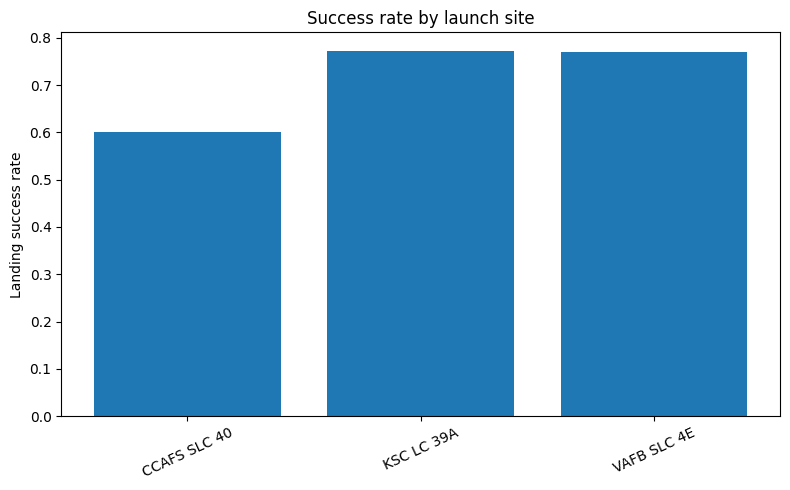

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('../data/clean_spacex.csv')
rates=df.groupby('LaunchSite')['Class'].mean()
plt.figure(figsize=(8,5)); plt.bar(rates.index,rates.values); plt.xticks(rotation=25); plt.ylabel('Landing success rate'); plt.title('Success rate by launch site'); plt.tight_layout(); plt.show()

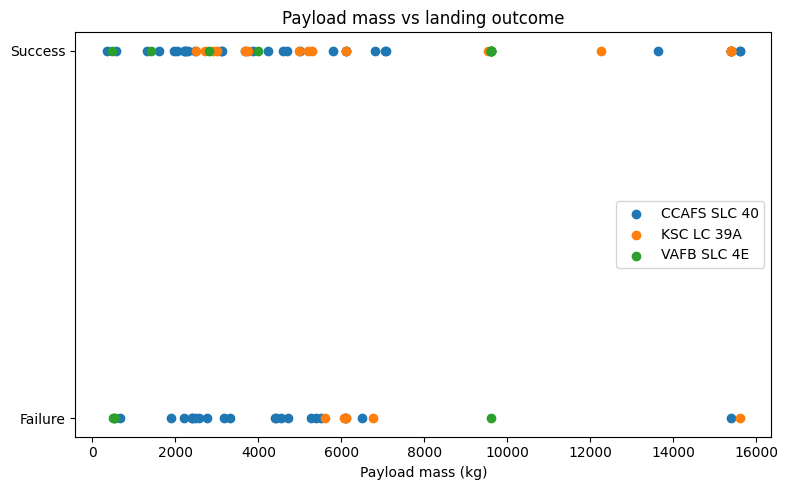

In [2]:
plt.figure(figsize=(8,5))
for site,grp in df.groupby('LaunchSite'):
    plt.scatter(grp['PayloadMass'],grp['Class'],label=site)
plt.yticks([0,1],['Failure','Success']); plt.xlabel('Payload mass (kg)'); plt.title('Payload mass vs landing outcome'); plt.legend(); plt.tight_layout(); plt.show()

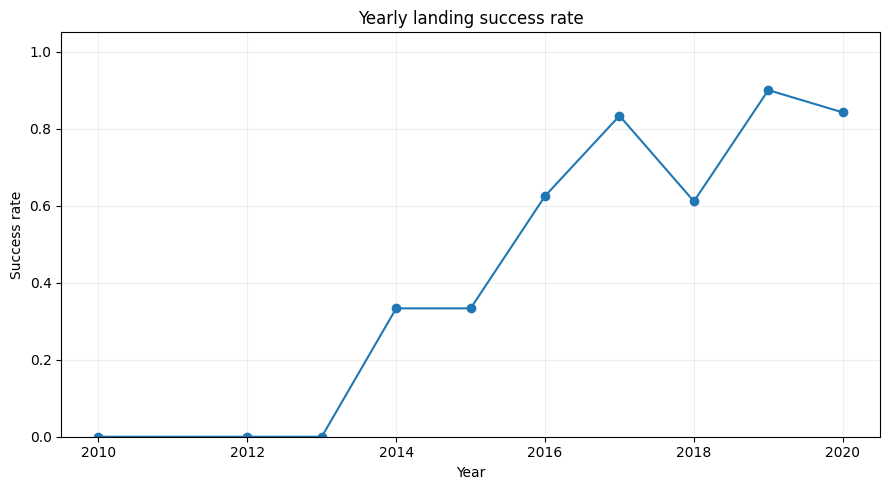

In [3]:
year=df.assign(Year=pd.to_datetime(df['Date']).dt.year).groupby('Year')['Class'].agg(['count','mean']).reset_index()
plt.figure(figsize=(9,5)); plt.plot(year['Year'],year['mean'],marker='o'); plt.ylim(0,1.05); plt.title('Yearly landing success rate'); plt.ylabel('Success rate'); plt.xlabel('Year'); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

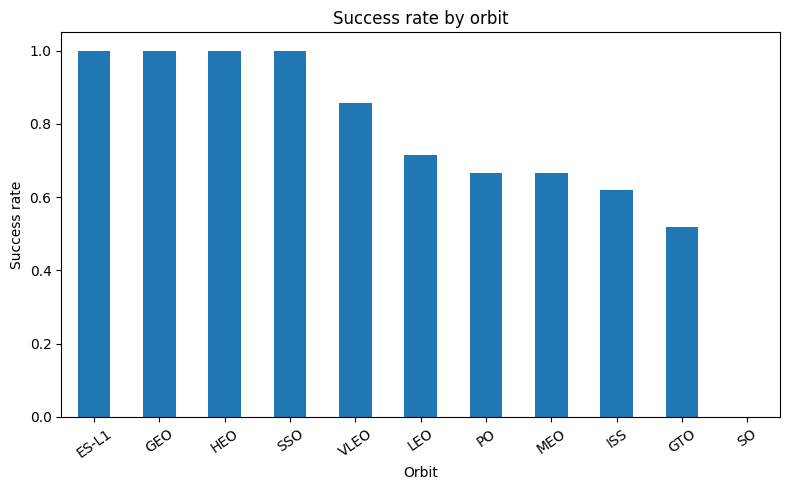

In [4]:
orbit=df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5)); orbit.plot(kind='bar'); plt.ylabel('Success rate'); plt.title('Success rate by orbit'); plt.xticks(rotation=35); plt.tight_layout(); plt.show()

In [5]:
print('Key observations')
print('- Later years show a marked increase in landing success as booster reuse becomes routine.')
print('- Launch site and mission profile are strongly associated with outcomes.')
print('- Payload mass alone does not perfectly separate successes and failures.')

Key observations
- Later years show a marked increase in landing success as booster reuse becomes routine.
- Launch site and mission profile are strongly associated with outcomes.
- Payload mass alone does not perfectly separate successes and failures.
